In [1]:
import pandas as pd

df = pd.read_csv("ftse100_close_2015_2026.csv", parse_dates=["date"], index_col="date")
df.head()

,close
date,
2015-01-02,6547.799805
2015-01-05,6417.200195
2015-01-06,6366.500000
2015-01-07,6419.799805
2015-01-08,6570.000000


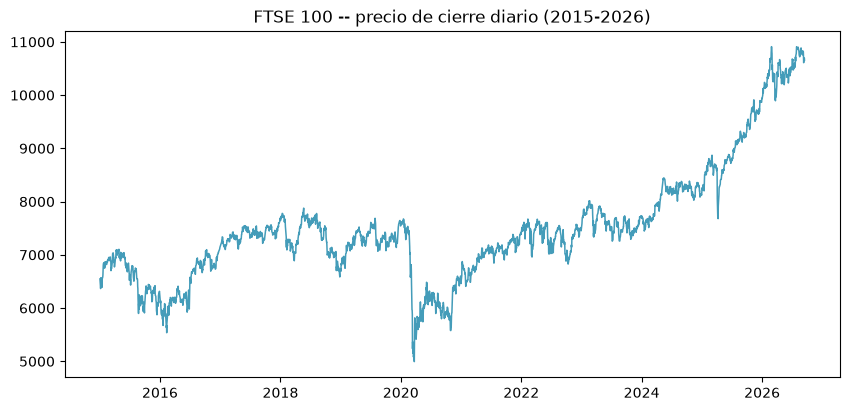

In [2]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(df.index, df["close"], color="#449cb9", linewidth=1.1)
ax.set_title("FTSE 100 -- precio de cierre diario (2015-2026)")
plt.savefig("ftse-precio-nivel.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df["close"])
print("ADF statistic:", resultado[0])
print("p-value:", resultado[1])
print("valores criticos:", resultado[4])

ADF statistic: -0.5147979664036224
p-value: 0.8890962795900094
valores criticos: {'1%': np.float64(-3.432564886510389), '5%': np.float64(-2.862518591340487), '10%': np.float64(-2.567290930826469)}


/var/folders/1k/2gl0gzxd1t12r58tgchyn4dc0000gn/T/ipykernel_21921/739169371.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(df["close"])


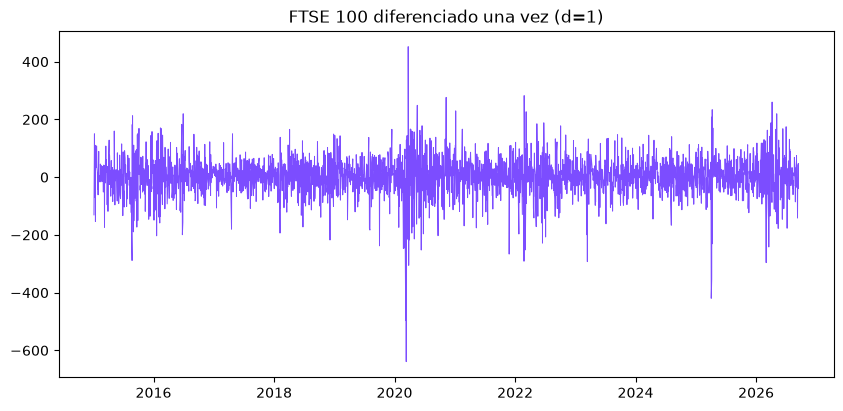

In [4]:
ftse_diff = df["close"].diff().dropna()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ftse_diff.index, ftse_diff, color="#7c4dff", linewidth=0.7)
ax.set_title("FTSE 100 diferenciado una vez (d=1)")
plt.savefig("ftse-precio-diferenciado.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
resultado_diff = adfuller(ftse_diff)
print("ADF statistic:", resultado_diff[0])
print("p-value:", resultado_diff[1])
print("valores criticos:", resultado_diff[4])

ADF statistic: -12.257039432048703
p-value: 9.259697468759234e-23
valores criticos: {'1%': np.float64(-3.432583038656411), '5%': np.float64(-2.86252660839952), '10%': np.float64(-2.5672951990365)}


/var/folders/1k/2gl0gzxd1t12r58tgchyn4dc0000gn/T/ipykernel_21921/1143032545.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_diff = adfuller(ftse_diff)


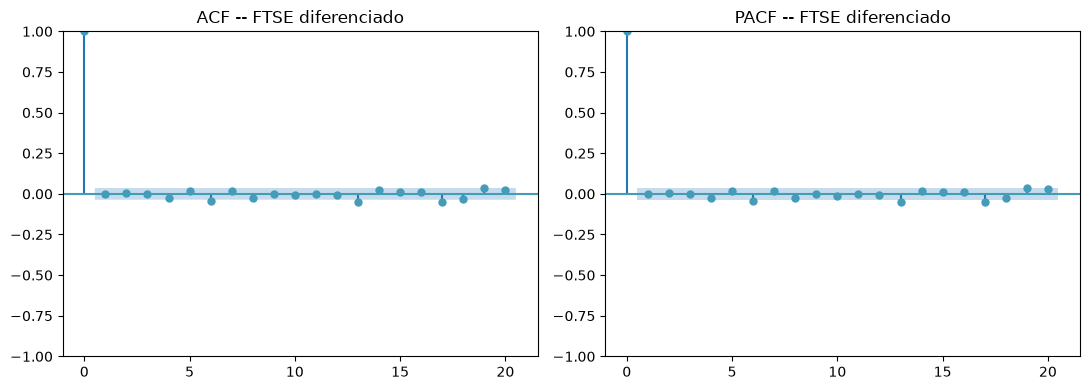

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_acf(ftse_diff, lags=20, ax=axes[0], color="#449cb9")
plot_pacf(ftse_diff, lags=20, ax=axes[1], color="#449cb9", method="ywm")
axes[0].set_title("ACF -- FTSE diferenciado")
axes[1].set_title("PACF -- FTSE diferenciado")
plt.tight_layout()
plt.savefig("ftse-acf-pacf-diferenciado.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
from statsmodels.tsa.arima.model import ARIMA

modelo = ARIMA(df["close"], order=(1, 1, 1))
resultado_arima = modelo.fit()
print(resultado_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 2956
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -16600.861
Date:                Wed, 16 Sep 2026   AIC                          33207.722
Time:                        18:49:17   BIC                          33225.695
Sample:                             0   HQIC                         33214.192
                               - 2956                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8728      0.136     -6.429      0.000      -1.139      -0.607
ma.L1          0.8846      0.131      6.748      0.000       0.628       1.142
sigma2      4436.4693     58.240     76.175      0.0

/Users/juangabriel/.cache/uv/archive-v0/dW2Qo-dJS1TMINvy/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/juangabriel/.cache/uv/archive-v0/dW2Qo-dJS1TMINvy/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/juangabriel/.cache/uv/archive-v0/dW2Qo-dJS1TMINvy/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


In [8]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos = resultado_arima.resid
lb = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(lb)
print()
print("media de los residuos:", residuos.mean())
print("desviacion tipica de los residuos:", residuos.std())

     lb_stat  lb_pvalue
10  4.149107    0.94037

media de los residuos: 3.5966158792225307
desviacion tipica de los residuos: 137.59964532575034
